# Level 5 — Recommendation Intelligence AI
### Agentic Architecture Demo

---

## What is the Agentic Level 5 AI?

This notebook demonstrates the **Agentic** implementation of Level 5 Recommendation Intelligence.
Each use case has **two versions**:

| Version | Description |
|---|---|
| **A — Deterministic** | Fixed tool path, baseline behaviour, nonagentic-compatible output |
| **B — Dynamic** | Planner generates steps, registry discovers tools, optional LLM reasoning |

## Agentic Capabilities Demonstrated

- **Planning** — multi-step reasoning with structured execution plans
- **Dynamic Tool Discovery** — registry-based tool selection
- **Dynamic SQL Generation** — safe read-only SQL from natural language (UC6, UC7)
- **MCP Tool Layer** — all tools exposed via MCP servers
- **Hybrid ML + LLM** — classical models + LLM reasoning (with deterministic fallback)
- **Memory** — plan history, tool usage, evaluation history
- **Explainability** — dominant signal, feature selection, agent path

## Use Cases

| UC | Name | Strategy |
|---|---|---|
| UC1 | User-Based Recommendations | Segment peer behaviour |
| UC2 | Collaborative Filtering | User-user cosine similarity |
| UC3 | Behaviour-Based Ranking | Clicks, views, purchases |
| UC4 | Hybrid Recommender | Weighted combination of all signals |
| UC5 | Cold Start Handling | Segment/popularity fallback |
| UC6 | Cross-User Segment | Batch recommendations for segment |
| UC7 | Recommendation Evaluation | Offline metrics + leakage detection |
| UC8 | Visualisation | Charts and summaries |
| UC9 | Orchestrator Routing | Dynamic intent classification |

---

## Setup

Run this cell once to initialise both the nonagentic and agentic systems.

In [1]:
import sys, os
from pathlib import Path

_root = Path(os.getcwd())
while not (_root / 'nonagentic' / '__init__.py').exists() and _root != _root.parent:
    _root = _root.parent
os.chdir(_root)
sys.path.insert(0, str(_root))
sys.path.insert(0, str(_root / 'notebooks' / 'nonagentic'))

from dotenv import load_dotenv
load_dotenv()
os.environ['GUARDRAIL_ENABLED'] = 'false'

import pandas as pd
from collections import Counter, defaultdict
from IPython.display import display, HTML

# ── Nonagentic imports (for baseline + output compatibility) ──────────────────
from nonagentic.tools.recommender import (
    recommend, _load_customers, _load_interactions, _load_products,
    _build_user_item_matrix, _cosine, _collaborative_scores,
)
from nonagentic.recommenders import (
    get_segment_recommendations, get_similar_users,
    get_behaviour_scores, get_content_scores, get_category_affinity,
    get_cold_start_recommendations, get_segment_recommendations_batch,
    evaluate_batch, check_data_leakage,
)
from nonagentic.recommenders.dataset import get_interaction_stats, get_category_stats, get_segment_stats
from notebooks.nonagentic.utils import (
    display_metrics, display_bar_chart, display_section,
    show_rec_table, show_sim_table, show_eval_metrics, show_leakage_table,
    build_seg_rows, build_sim_rows, build_collab_rows, build_behav_rows,
    build_hybrid_rows, build_cold_rows, build_seg_batch_rows, build_precision_buckets,
    plot_similarity_heatmap, plot_score_distribution, plot_category_coverage,
)

# ── Agentic imports ───────────────────────────────────────────────────────────
from agentic.utils.agentic_api import create_api
from notebooks.agentic.utils.display_helper import (
    show_llm_feature_priority, show_llm_strategy_selection, show_llm_explanation,
    show_running_banner, show_generated_sql, show_llm_weight_proposal,
    show_llm_request_classification, show_routing_request_header, show_routing_divider,
)
from agentic.utils.agentic_display import (
    show_agentic_result, show_agent_plan, show_agent_reasoning,
    show_tool_selection, show_agent_path,
    show_memory_updates, show_mcp_calls, show_model_choice,
    show_feature_selection, show_comparison,
)
from agentic.mcp import recommendation_server as rec_mcp
from agentic.mcp import llm_reasoning_server as llm_mcp
from agentic.sql.sql_generator import generate_sql

# ── Shared data ───────────────────────────────────────────────────────────────
CUSTOMERS    = _load_customers()
INTERACTIONS = _load_interactions()
PRODUCTS     = _load_products()
MATRIX       = _build_user_item_matrix(INTERACTIONS)
PROD_MAP     = {p['product_id']: p for p in PRODUCTS}
CUST_MAP     = {c['customer_id']: c for c in CUSTOMERS}

api = create_api()

print('✅ Level 5 Agentic Recommendation AI Ready')
print(f'   {len(CUSTOMERS)} customers | {len(PRODUCTS)} products | {len(INTERACTIONS)} interactions')
print('   Two versions per use case: A=Deterministic  B=Dynamic')



✅ Level 5 Agentic Recommendation AI Ready
   208 customers | 200 products | 12000 interactions
   Two versions per use case: A=Deterministic  B=Dynamic


---
## Section 1 — Dataset Overview

**Business scenario**: Before running recommendations, understand the shape of the interaction data.

In [2]:
itype_counts = get_interaction_stats(INTERACTIONS)
cat_counts   = get_category_stats([{**i, 'category': PROD_MAP.get(i['product_id'], {}).get('category', 'unknown')} for i in INTERACTIONS])
seg_counts   = get_segment_stats(CUSTOMERS)

display_metrics({
    'Customers':    len(CUSTOMERS),
    'Products':     len(PRODUCTS),
    'Interactions': len(INTERACTIONS),
    'Categories':   len(set(p['category'] for p in PRODUCTS)),
})
display_bar_chart(itype_counts, '📊 Interactions by Type',     color='#667eea')
display_bar_chart(seg_counts,   '👥 Customers by Segment',      color='#10b981')
display_bar_chart(cat_counts,   '🛒 Interactions by Category', color='#f59e0b')

---
## Use Case 1 — User-Based Recommendations

**Business scenario**: Recommend items to a customer based on what customers in the same segment tend to buy.

| Version | Approach |
|---|---|
| **A — Deterministic** | Fixed call to `segment_recommendations` MCP tool |
| **B — Dynamic** | Planner chooses between segment-based, collaborative, or behaviour-based depending on available data |

In [3]:
# ── UC1-A: Deterministic ──────────────────────────────────────────────────────
display_section('🅐 UC1-A — User-Based Recommendations (Deterministic)')

customer_id = 'CUST-001'
cust        = CUST_MAP[customer_id]
segment     = cust['segment']

display_metrics({
    'Customer ID': customer_id,
    'Segment':     segment,
    'Engagement':  f"{cust.get('engagement_score', 0):.1%}",
    'Categories':  ', '.join(cust.get('purchase_categories', [])),
})

# Direct MCP call (deterministic)
mcp_result = rec_mcp.segment_recommendations(segment, top_k=10)
top_seg    = mcp_result['result']

display_section(f'👥 User-Based Recommendations for {customer_id} (segment: {segment})')
show_rec_table(build_seg_rows(top_seg, segment, PROD_MAP),
               gradient_col='Segment Score', header_color='#10b981', cmap='Greens',
               fmt={'Segment Score': '{:.3f}'})

seg_peers = {c['customer_id'] for c in CUSTOMERS if c.get('segment') == segment}
display_metrics({'Segment Peers': len(seg_peers) - 1, 'Candidate Items': len(top_seg), 'Returned': len(top_seg)})

Product ID,Name,Category,Segment Score,Explanation
PROD-052,Leggings,clothing,1.000,Popular in 'casual' segment
PROD-057,Hat,clothing,0.988,Popular in 'casual' segment
PROD-045,Jacket,clothing,0.975,Popular in 'casual' segment
PROD-058,Gloves,clothing,0.938,Popular in 'casual' segment
PROD-048,Coat,clothing,0.938,Popular in 'casual' segment
PROD-047,Dress,clothing,0.914,Popular in 'casual' segment
PROD-049,Hoodie,clothing,0.914,Popular in 'casual' segment
PROD-198,Mirrors,automotive,0.889,Popular in 'casual' segment
PROD-137,Cleanser,beauty,0.877,Popular in 'casual' segment
PROD-041,T-Shirt,clothing,0.864,Popular in 'casual' segment


In [4]:
# ── UC1-B: Dynamic ────────────────────────────────────────────────────────────
display_section('🅑 UC1-B — User-Based Recommendations (Dynamic Agentic)')

result_b = api.execute_rec_uc1_user_based(customer_id, segment, top_k=10, mode='dynamic')

show_agentic_result(result_b)
show_agent_plan(result_b)
show_agent_reasoning(result_b)
show_tool_selection(result_b)
show_agent_path(result_b)
show_model_choice(result_b)
show_memory_updates(result_b)
show_mcp_calls(result_b)

# Output compatibility: same business view
display_section(f'👥 User-Based Recommendations for {customer_id} (segment: {segment})')
show_rec_table(build_seg_rows(top_seg, segment, PROD_MAP),
               gradient_col='Segment Score', header_color='#10b981', cmap='Greens',
               fmt={'Segment Score': '{:.3f}'})
display_metrics({'Mode': 'Dynamic', 'Segment': segment, 'Returned': len(top_seg)})

Product ID,Name,Category,Segment Score,Explanation
PROD-052,Leggings,clothing,1.000,Popular in 'casual' segment
PROD-057,Hat,clothing,0.988,Popular in 'casual' segment
PROD-045,Jacket,clothing,0.975,Popular in 'casual' segment
PROD-058,Gloves,clothing,0.938,Popular in 'casual' segment
PROD-048,Coat,clothing,0.938,Popular in 'casual' segment
PROD-047,Dress,clothing,0.914,Popular in 'casual' segment
PROD-049,Hoodie,clothing,0.914,Popular in 'casual' segment
PROD-198,Mirrors,automotive,0.889,Popular in 'casual' segment
PROD-137,Cleanser,beauty,0.877,Popular in 'casual' segment
PROD-041,T-Shirt,clothing,0.864,Popular in 'casual' segment


---
## Use Case 2 — Collaborative Filtering

**Business scenario**: Find customers with similar interaction patterns and use their preferences to recommend products.

| Version | Approach |
|---|---|
| **A — Deterministic** | Fixed cosine similarity pipeline |
| **B — Dynamic** | Planner selects collaborative strategy from registry (user-user, item-item, segment fallback) |

In [5]:
# ── UC2-A: Deterministic ──────────────────────────────────────────────────────
display_section('🅐 UC2-A — Collaborative Filtering (Deterministic)')

customer_id = 'CUST-001'
mcp_result  = rec_mcp.collaborative_scores(customer_id, top_k=8)
cf_data     = mcp_result['result']
similar_users = cf_data['similar_users']

display_section('🔗 Most Similar Users (Cosine Similarity)')
show_sim_table(build_sim_rows(similar_users, MATRIX.get(customer_id, {}), MATRIX, CUST_MAP, _cosine))

collab_scores, _ = _collaborative_scores(customer_id, MATRIX)
top_collab = sorted(collab_scores.items(), key=lambda x: -x[1])[:8]

display_section('🎯 Collaborative Filtering Recommendations')
show_rec_table(build_collab_rows(top_collab, PROD_MAP),
               gradient_col='CF Score', header_color='#8b5cf6', cmap='Purples',
               fmt={'CF Score': '{:.3f}'})
display_metrics({'Similar Users Found': len(similar_users), 'Candidate Items': len(collab_scores),
                 'Top Recommendation': top_collab[0][0] if top_collab else 'none'})

Customer ID,Segment,Similarity,Interactions,Categories
CUST-016,casual,0.435,30,home
CUST-173,vip,0.430,38,"home, beauty, clothing"
CUST-127,at_risk,0.427,36,"home, clothing"
CUST-015,casual,0.406,33,home
CUST-019,dormant_vip,0.403,22,home
CUST-107,vip,0.393,35,"home, clothing"
CUST-128,dormant_vip,0.389,32,"books, travel, home"
CUST-014,at_risk,0.389,26,books


Product ID,Name,Category,CF Score
PROD-045,Jacket,clothing,1.000
PROD-053,Blazer,clothing,0.983
PROD-055,Cardigan,clothing,0.887
PROD-047,Dress,clothing,0.776
PROD-016,Advanced Python,books,0.736
PROD-003,AI Fundamentals,books,0.677
PROD-078,Lamp,home,0.673
PROD-010,Yoga for Beginners,books,0.611


In [6]:
# ── UC2-B: Dynamic ────────────────────────────────────────────────────────────
display_section('🅑 UC2-B — Collaborative Filtering (Dynamic Agentic)')

result_b = api.execute_rec_uc2_collaborative(customer_id, top_k=8, mode='dynamic')

show_agentic_result(result_b)
show_agent_plan(result_b)
show_agent_reasoning(result_b)
show_tool_selection(result_b)
show_agent_path(result_b)
show_model_choice(result_b)
show_memory_updates(result_b)
show_mcp_calls(result_b)

# Output compatibility
display_section('🔗 Most Similar Users (Cosine Similarity)')
show_sim_table(build_sim_rows(similar_users, MATRIX.get(customer_id, {}), MATRIX, CUST_MAP, _cosine))
display_section('🎯 Collaborative Filtering Recommendations')
show_rec_table(build_collab_rows(top_collab, PROD_MAP),
               gradient_col='CF Score', header_color='#8b5cf6', cmap='Purples',
               fmt={'CF Score': '{:.3f}'})

Customer ID,Segment,Similarity,Interactions,Categories
CUST-016,casual,0.435,30,home
CUST-173,vip,0.430,38,"home, beauty, clothing"
CUST-127,at_risk,0.427,36,"home, clothing"
CUST-015,casual,0.406,33,home
CUST-019,dormant_vip,0.403,22,home
CUST-107,vip,0.393,35,"home, clothing"
CUST-128,dormant_vip,0.389,32,"books, travel, home"
CUST-014,at_risk,0.389,26,books


Product ID,Name,Category,CF Score
PROD-045,Jacket,clothing,1.000
PROD-053,Blazer,clothing,0.983
PROD-055,Cardigan,clothing,0.887
PROD-047,Dress,clothing,0.776
PROD-016,Advanced Python,books,0.736
PROD-003,AI Fundamentals,books,0.677
PROD-078,Lamp,home,0.673
PROD-010,Yoga for Beginners,books,0.611


---
## Use Case 3 — Behaviour-Based Ranking

**Business scenario**: Rank products based on a customer's own clicks, views, and purchases, weighted by engagement.

| Version | Approach |
|---|---|
| **A — Deterministic** | Fixed behaviour + content score computation |
| **B — Dynamic** | Planner asks LLM reasoner to suggest feature emphasis; chooses between hand-crafted features and learned scoring |

In [7]:
# ── UC3-A: Deterministic ──────────────────────────────────────────────────────
display_section('🅐 UC3-A — Behaviour-Based Ranking (Deterministic)')

customer_id    = 'CUST-001'
cust           = CUST_MAP[customer_id]
behav_scores   = get_behaviour_scores(cust, PRODUCTS)
content_scores = get_content_scores(cust, PRODUCTS)

display_metrics({
    'Purchase Categories':  ', '.join(cust.get('purchase_categories', [])),
    'Engagement Score':     f"{cust.get('engagement_score', 0):.1%}",
    'Behaviour Candidates': len(behav_scores),
    'Content Candidates':   len(content_scores),
})

display_section('🧠 Behaviour + Content Signal Scores')
show_rec_table(build_behav_rows(behav_scores, content_scores, PROD_MAP),
               gradient_col='Combined', header_color='#f59e0b', cmap='Oranges',
               fmt={'Behaviour Score': '{:.3f}', 'Content Score': '{:.3f}', 'Combined': '{:.3f}'})

cat_affinity = get_category_affinity(behav_scores, PRODUCTS)
display_bar_chart(dict(sorted(cat_affinity.items(), key=lambda x: -x[1])[:6]),
                  '📊 Category Affinity Scores', color='#f59e0b')

Product ID,Name,Category,Behaviour Score,Content Score,Combined
PROD-015,Travel Photography,books,0.800,0.333,0.613
PROD-066,Bed Sheets,home,0.800,0.333,0.613
PROD-062,Air Purifier,home,0.640,0.333,0.517
PROD-080,Curtains,home,0.640,0.333,0.517
PROD-069,Wall Clock,home,0.640,0.333,0.517
PROD-018,Blockchain Basics,books,0.640,0.333,0.517
PROD-064,Blender,home,0.640,0.333,0.517
PROD-060,Underwear,clothing,0.640,0.333,0.517
PROD-012,Mystery Thriller,books,0.640,0.333,0.517
PROD-068,Scented Candle,home,0.640,0.333,0.517


In [8]:
# ── UC3-B: Dynamic ────────────────────────────────────────────────────────────
display_section('🅑 UC3-B — Behaviour-Based Ranking (Dynamic Agentic)')

result_b = api.execute_rec_uc3_behaviour(customer_id, top_k=10, mode='dynamic')

show_agentic_result(result_b)
show_agent_plan(result_b)
show_agent_reasoning(result_b)
show_tool_selection(result_b)
show_feature_selection(result_b)
show_model_choice(result_b)
show_agent_path(result_b)
show_memory_updates(result_b)
show_mcp_calls(result_b)

# Dynamic: LLM feature priority suggestion
context     = {'engagement_score': cust.get('engagement_score', 0), 'purchase_categories': cust.get('purchase_categories', [])}
feat_result = llm_mcp.suggest_feature_priority(customer_id, context)
show_llm_feature_priority(feat_result['result']['features'])

# Output compatibility
display_section('🧠 Behaviour + Content Signal Scores')
show_rec_table(build_behav_rows(behav_scores, content_scores, PROD_MAP),
               gradient_col='Combined', header_color='#f59e0b', cmap='Oranges',
               fmt={'Behaviour Score': '{:.3f}', 'Content Score': '{:.3f}', 'Combined': '{:.3f}'})


Product ID,Name,Category,Behaviour Score,Content Score,Combined
PROD-015,Travel Photography,books,0.800,0.333,0.613
PROD-066,Bed Sheets,home,0.800,0.333,0.613
PROD-062,Air Purifier,home,0.640,0.333,0.517
PROD-080,Curtains,home,0.640,0.333,0.517
PROD-069,Wall Clock,home,0.640,0.333,0.517
PROD-018,Blockchain Basics,books,0.640,0.333,0.517
PROD-064,Blender,home,0.640,0.333,0.517
PROD-060,Underwear,clothing,0.640,0.333,0.517
PROD-012,Mystery Thriller,books,0.640,0.333,0.517
PROD-068,Scented Candle,home,0.640,0.333,0.517


---
## Use Case 4 — Hybrid Recommender

**Business scenario**: Combine collaborative filtering, behaviour signals, content similarity, and popularity into one ranked list.

```
score = 0.4 × collaborative + 0.3 × behaviour + 0.2 × content + 0.1 × popularity
```

| Version | Approach |
|---|---|
| **A — Deterministic** | Fixed weighted hybrid with configured weights |
| **B — Dynamic** | Planner selects candidate models from registry + LLM-assisted ranking explanation |

In [9]:
# ── UC4-A: Deterministic ──────────────────────────────────────────────────────
display_section('🅐 UC4-A — Hybrid Recommender (Deterministic)')

customer_id = 'CUST-001'
result      = recommend(customer_id, top_k=10)
recs        = result['recommendations']

display_section(f'🏆 Hybrid Recommendations for {customer_id}')
show_rec_table(build_hybrid_rows(recs, PROD_MAP),
               gradient_col='Score', header_color='#667eea', cmap='RdYlGn',
               fmt={'Score': '{:.3f}', 'Confidence': '{:.3f}'})

display_metrics({
    'Recommendations': len(recs),
    'Top Score':        f"{recs[0]['score']:.3f}" if recs else 'n/a',
    'Similar Users':    len(result.get('similar_users', [])),
    'Cold Start':       str(result.get('cold_start', False)),
})
display_bar_chart(dict(Counter(r['source_model'] for r in recs)),
                  '📊 Recommendations by Source Model', color='#667eea')

Rank,Product ID,Name,Category,Score,Confidence,Explanation
1,PROD-053,Blazer,clothing,0.628,0.691,Customers similar to you purchased this item
2,PROD-045,Jacket,clothing,0.621,0.684,Customers similar to you purchased this item
3,PROD-055,Cardigan,clothing,0.602,0.662,Customers similar to you purchased this item
4,PROD-047,Dress,clothing,0.551,0.606,Popular item among all customers
5,PROD-016,Advanced Python,books,0.530,0.583,Popular item among all customers
6,PROD-003,AI Fundamentals,books,0.522,0.574,Popular item among all customers
7,PROD-010,Yoga for Beginners,books,0.491,0.540,Popular item among all customers
8,PROD-019,Quantum Computing,books,0.448,0.493,Popular item among all customers
9,PROD-006,Machine Learning,books,0.443,0.487,Popular item among all customers
10,PROD-078,Lamp,home,0.442,0.486,Customers similar to you purchased this item


In [10]:
# ── UC4-B: Dynamic ────────────────────────────────────────────────────────────
display_section('🅑 UC4-B — Hybrid Recommender (Dynamic Agentic)')

result_b = api.execute_rec_uc4_hybrid(customer_id, top_k=10, mode='dynamic')

show_agentic_result(result_b)
show_agent_plan(result_b)
show_agent_reasoning(result_b)
show_tool_selection(result_b)
show_model_choice(result_b)
show_agent_path(result_b)
show_memory_updates(result_b)
show_mcp_calls(result_b)

# Dynamic: LLM strategy selection
cust    = CUST_MAP[customer_id]
context = {
    'interaction_count': len([i for i in INTERACTIONS if i['customer_id'] == customer_id]),
    'engagement_score':  cust.get('engagement_score', 0),
    'purchase_categories': cust.get('purchase_categories', []),
}
strat_result = llm_mcp.choose_recommendation_strategy(customer_id, context)
strat        = strat_result['result']
show_llm_strategy_selection(strat)

# Dynamic: LLM explanation for top recommendation
if recs:
    top_rec = recs[0]
    signals = {
        'collaborative': top_rec.get('collaborative_score', 0),
        'behaviour':     top_rec.get('behaviour_score', 0),
        'content':       top_rec.get('content_score', 0),
        'popularity':    top_rec.get('popularity_score', 0),
    }
    expl_result = llm_mcp.explain_recommendation(top_rec['product_id'], customer_id, signals)
    show_llm_explanation(top_rec, expl_result['result'])

# Output compatibility
display_section(f'🏆 Hybrid Recommendations for {customer_id}')
show_rec_table(build_hybrid_rows(recs, PROD_MAP),
               gradient_col='Score', header_color='#667eea', cmap='RdYlGn',
               fmt={'Score': '{:.3f}', 'Confidence': '{:.3f}'})


Rank,Product ID,Name,Category,Score,Confidence,Explanation
1,PROD-053,Blazer,clothing,0.628,0.691,Customers similar to you purchased this item
2,PROD-045,Jacket,clothing,0.621,0.684,Customers similar to you purchased this item
3,PROD-055,Cardigan,clothing,0.602,0.662,Customers similar to you purchased this item
4,PROD-047,Dress,clothing,0.551,0.606,Popular item among all customers
5,PROD-016,Advanced Python,books,0.530,0.583,Popular item among all customers
6,PROD-003,AI Fundamentals,books,0.522,0.574,Popular item among all customers
7,PROD-010,Yoga for Beginners,books,0.491,0.540,Popular item among all customers
8,PROD-019,Quantum Computing,books,0.448,0.493,Popular item among all customers
9,PROD-006,Machine Learning,books,0.443,0.487,Popular item among all customers
10,PROD-078,Lamp,home,0.442,0.486,Customers similar to you purchased this item


---
## Use Case 5 — Cold Start Handling

**Business scenario**: A brand-new customer has no purchase history. The system must still return useful recommendations.

**Cold start strategy**:
1. Detect: fewer than 3 interactions → cold start
2. Fallback: return top popular items filtered by the customer's segment
3. If segment unknown: return global top-K popular items

| Version | Approach |
|---|---|
| **A — Deterministic** | Fixed segment fallback or popularity fallback |
| **B — Dynamic** | Planner + LLM reasoner decide among: popularity, segment peer behaviour, content-only, product metadata similarity |

In [11]:
# ── UC5-A: Deterministic ──────────────────────────────────────────────────────
display_section('🅐 UC5-A — Cold Start Handling (Deterministic)')

cold_cust = {'customer_id': 'CUST-NEW', 'segment': 'dormant_vip',
             'purchase_categories': [], 'engagement_score': 0.1}
segment   = cold_cust['segment']

top_cold  = get_cold_start_recommendations(cold_cust, INTERACTIONS, PRODUCTS, customers=CUSTOMERS, top_k=10)
seg_peers = {c['customer_id'] for c in CUSTOMERS if c.get('segment') == segment}

display_section(f'🌱 Cold Start Recommendations ({segment} segment)')
show_rec_table(build_cold_rows(top_cold, segment, PROD_MAP),
               gradient_col='Score', header_color='#f59e0b', cmap='YlOrRd',
               fmt={'Score': '{:.3f}'})
display_metrics({'Strategy': 'Segment Fallback', 'Segment': segment,
                 'Segment Peers': len(seg_peers), 'Items Returned': len(top_cold)})

Product ID,Name,Category,Score,Source,Explanation
PROD-083,Cable Organiser,electronics,1.000,segment_fallback,Popular in 'dormant_vip' segment
PROD-056,Scarf,clothing,1.000,segment_fallback,Popular in 'dormant_vip' segment
PROD-130,Mascara,beauty,0.922,segment_fallback,Popular in 'dormant_vip' segment
PROD-134,Nail Polish,beauty,0.906,segment_fallback,Popular in 'dormant_vip' segment
PROD-016,Advanced Python,books,0.906,segment_fallback,Popular in 'dormant_vip' segment
PROD-196,Spark Plugs,automotive,0.906,segment_fallback,Popular in 'dormant_vip' segment
PROD-045,Jacket,clothing,0.875,segment_fallback,Popular in 'dormant_vip' segment
PROD-094,Screen Protector,electronics,0.859,segment_fallback,Popular in 'dormant_vip' segment
PROD-084,USB Hub,electronics,0.844,segment_fallback,Popular in 'dormant_vip' segment
PROD-115,Hiking Boots,sports,0.844,segment_fallback,Popular in 'dormant_vip' segment


In [12]:
# ── UC5-B: Dynamic ────────────────────────────────────────────────────────────
display_section('🅑 UC5-B — Cold Start Handling (Dynamic Agentic)')

result_b = api.execute_rec_uc5_cold_start('CUST-NEW', segment, top_k=10, mode='dynamic')

show_agentic_result(result_b)
show_agent_plan(result_b)
show_agent_reasoning(result_b)
show_tool_selection(result_b)
show_model_choice(result_b)
show_agent_path(result_b)
show_memory_updates(result_b)
show_mcp_calls(result_b)

# Dynamic: LLM fallback decision
context      = {'interaction_count': 0, 'engagement_score': 0.1, 'purchase_categories': []}
strat_result = llm_mcp.choose_recommendation_strategy('CUST-NEW', context)
strat        = {**strat_result['result'], 'label': '🤖 LLM Fallback Decision (Dynamic)'}
show_llm_strategy_selection(strat)

# Output compatibility
display_section(f'🌱 Cold Start Recommendations ({segment} segment)')
show_rec_table(build_cold_rows(top_cold, segment, PROD_MAP),
               gradient_col='Score', header_color='#f59e0b', cmap='YlOrRd',
               fmt={'Score': '{:.3f}'})


Product ID,Name,Category,Score,Source,Explanation
PROD-083,Cable Organiser,electronics,1.000,segment_fallback,Popular in 'dormant_vip' segment
PROD-056,Scarf,clothing,1.000,segment_fallback,Popular in 'dormant_vip' segment
PROD-130,Mascara,beauty,0.922,segment_fallback,Popular in 'dormant_vip' segment
PROD-134,Nail Polish,beauty,0.906,segment_fallback,Popular in 'dormant_vip' segment
PROD-016,Advanced Python,books,0.906,segment_fallback,Popular in 'dormant_vip' segment
PROD-196,Spark Plugs,automotive,0.906,segment_fallback,Popular in 'dormant_vip' segment
PROD-045,Jacket,clothing,0.875,segment_fallback,Popular in 'dormant_vip' segment
PROD-094,Screen Protector,electronics,0.859,segment_fallback,Popular in 'dormant_vip' segment
PROD-084,USB Hub,electronics,0.844,segment_fallback,Popular in 'dormant_vip' segment
PROD-115,Hiking Boots,sports,0.844,segment_fallback,Popular in 'dormant_vip' segment


---
## Use Case 6 — Cross-User Segment Recommendations

**Business scenario**: Generate recommendations for an entire customer segment at once — e.g. all `dormant_vip` customers — to plan a re-engagement campaign.

| Version | Approach |
|---|---|
| **A — Deterministic** | Fixed batch recommendations for a segment |
| **B — Dynamic** | Planner generates SQL to identify segment members, then calls recommendation tools and aggregates results |

In [13]:
# ── UC6-A: Deterministic ──────────────────────────────────────────────────────
display_section('🅐 UC6-A — Cross-User Segment Recommendations (Deterministic)')

target_segment = 'dormant_vip'
seg_custs      = [c['customer_id'] for c in CUSTOMERS if c.get('segment') == target_segment][:15]

display_section(f'🎯 Cross-User Recommendations — Segment: {target_segment}')
show_running_banner(len(seg_custs))

top_seg_recs = get_segment_recommendations_batch(target_segment, CUSTOMERS, recommend, top_k=10, sample_size=15)

show_rec_table(build_seg_batch_rows(top_seg_recs, PROD_MAP),
               gradient_col='Avg Score', header_color='#10b981', cmap='Greens',
               fmt={'Avg Score': '{:.3f}'})

seg_cat_counts = Counter(PROD_MAP.get(pid, {}).get('category', '?') for pid, _ in top_seg_recs)
display_bar_chart(dict(seg_cat_counts), f"📊 Top Recommended Categories for '{target_segment}'", color='#10b981')
display_metrics({'Segment': target_segment, 'Customers Sampled': len(seg_custs),
                 'Unique Products': len(top_seg_recs), 'Top Product': top_seg_recs[0][0] if top_seg_recs else 'n/a'})


Product ID,Name,Category,Avg Score
PROD-014,Science Fiction Novel,books,0.683
PROD-185,Seat Covers,automotive,0.651
PROD-001,Python Guide,books,0.647
PROD-187,Car Organizer,automotive,0.640
PROD-118,Climbing Rope,sports,0.622
PROD-064,Blender,home,0.617
PROD-006,Machine Learning,books,0.572
PROD-188,Tire Gauge,automotive,0.562
PROD-019,Quantum Computing,books,0.556
PROD-018,Blockchain Basics,books,0.553


In [14]:
# ── UC6-B: Dynamic (with SQL generation) ─────────────────────────────────────
display_section('🅑 UC6-B — Cross-User Segment Recommendations (Dynamic + SQL)')

result_b = api.execute_rec_uc6_cross_segment(target_segment, top_k=10, sample_size=15, mode='dynamic')

show_agentic_result(result_b)
show_agent_plan(result_b)
show_agent_reasoning(result_b)
show_tool_selection(result_b)
show_agent_path(result_b)
show_memory_updates(result_b)
show_mcp_calls(result_b)

# Dynamic: show generated SQL
sql_query = generate_sql(f"Find all customers in {target_segment} segment")
show_generated_sql(sql_query)

# Output compatibility
display_section(f'🎯 Cross-User Recommendations — Segment: {target_segment}')
show_rec_table(build_seg_batch_rows(top_seg_recs, PROD_MAP),
               gradient_col='Avg Score', header_color='#10b981', cmap='Greens',
               fmt={'Avg Score': '{:.3f}'})


Product ID,Name,Category,Avg Score
PROD-014,Science Fiction Novel,books,0.683
PROD-185,Seat Covers,automotive,0.651
PROD-001,Python Guide,books,0.647
PROD-187,Car Organizer,automotive,0.640
PROD-118,Climbing Rope,sports,0.622
PROD-064,Blender,home,0.617
PROD-006,Machine Learning,books,0.572
PROD-188,Tire Gauge,automotive,0.562
PROD-019,Quantum Computing,books,0.556
PROD-018,Blockchain Basics,books,0.553


---
## Use Case 7 — Recommendation Evaluation

**Business scenario**: The data science team needs to measure how good the recommendations are before deploying to production.

**Offline evaluation protocol**:
1. For each user with ≥ 10 interactions, hold out the last 20% as ground truth
2. Generate top-K recommendations using the remaining 80%
3. Compute precision@K, recall@K, MAP, and NDCG

| Version | Approach |
|---|---|
| **A — Deterministic** | Fixed offline evaluation pipeline |
| **B — Dynamic** | Planner generates SQL to identify evaluation cohort, then runs metrics + LLM-assisted weight proposal |

In [15]:
# ── UC7-A: Deterministic ──────────────────────────────────────────────────────
display_section('🅐 UC7-A — Recommendation Evaluation (Deterministic)')

leakage_rows = check_data_leakage(INTERACTIONS, recommend, sample_users=10)
show_leakage_table(leakage_rows)

K       = 10
metrics = evaluate_batch(INTERACTIONS, lambda uid: recommend(uid, exclude_purchased=False), k=K, sample_users=40)
show_eval_metrics(metrics, K)

by_user  = defaultdict(list)
for rec in INTERACTIONS:
    by_user[rec['customer_id']].append(rec)
eligible   = {uid: recs for uid, recs in by_user.items() if len(recs) >= 10}
eval_users = list(eligible.keys())[:40]
buckets = build_precision_buckets(eval_users, eligible, recommend, k=K)
display_bar_chart(buckets, f'📊 Precision@{K} Distribution Across Users', color='#8b5cf6')

User,Train items,Test items (GT),GT∩Train (overlap),Hits excl=True,Hits excl=False,Leakage risk
CUST-139,40,14,8,0,2,⚠️ yes
CUST-143,38,13,8,0,7,⚠️ yes
CUST-166,34,13,7,0,5,⚠️ yes
CUST-005,45,13,5,0,5,⚠️ yes
CUST-055,23,11,11,0,11,⚠️ yes
CUST-116,51,17,7,0,0,⚠️ yes
CUST-001,46,13,6,0,4,⚠️ yes
CUST-008,51,15,5,0,0,⚠️ yes
CUST-109,45,15,8,0,1,⚠️ yes
CUST-114,40,15,11,0,5,⚠️ yes


In [16]:
# ── UC7-B: Dynamic (SQL cohort + LLM weight proposal) ────────────────────────
display_section('🅑 UC7-B — Recommendation Evaluation (Dynamic Agentic)')

result_b = api.execute_rec_uc7_evaluation(sample_users=40, k=10, mode='dynamic')

show_agentic_result(result_b)
show_agent_plan(result_b)
show_agent_reasoning(result_b)
show_tool_selection(result_b)
show_agent_path(result_b)
show_memory_updates(result_b)
show_mcp_calls(result_b)

# Dynamic: SQL to identify evaluation cohort
from agentic.sql.sql_generator import create_sql_generator
sql_gen    = create_sql_generator()
sql_result = sql_gen.generate('Find customers with enough interactions for evaluation', {'min_interactions': 10})
sql_query  = sql_result.get('query', 'SELECT customer_id FROM customers WHERE interaction_count >= 10 ORDER BY interaction_count DESC')
show_generated_sql(sql_query, title='💾 Generated SQL — Evaluation Cohort (Dynamic)')

# Dynamic: LLM proposes weight adjustments based on metrics
current_weights = {'collaborative': 0.4, 'behaviour': 0.3, 'content': 0.2, 'popularity': 0.1}
weight_result   = llm_mcp.propose_weight_adjustments(current_weights, metrics)
show_llm_weight_proposal(weight_result['result'])

# Output compatibility: same evaluation view
show_eval_metrics(metrics, K)


---
## Use Case 8 — Visualisation

**Business scenario**: The analytics team wants visual summaries of the recommendation engine — user similarity patterns, score distributions, and category coverage.

| Version | Approach |
|---|---|
| **A — Deterministic** | Fixed chart pipeline |
| **B — Dynamic** | Planner selects which charts to generate based on data profile; LLM classifies request type |


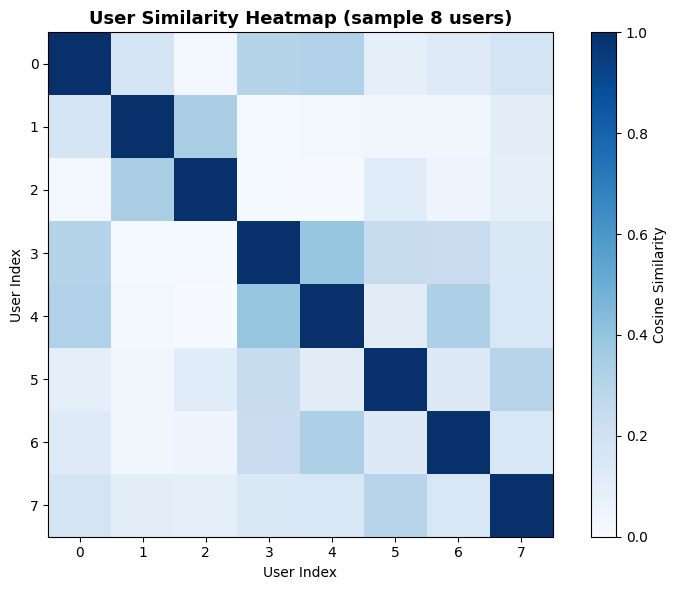


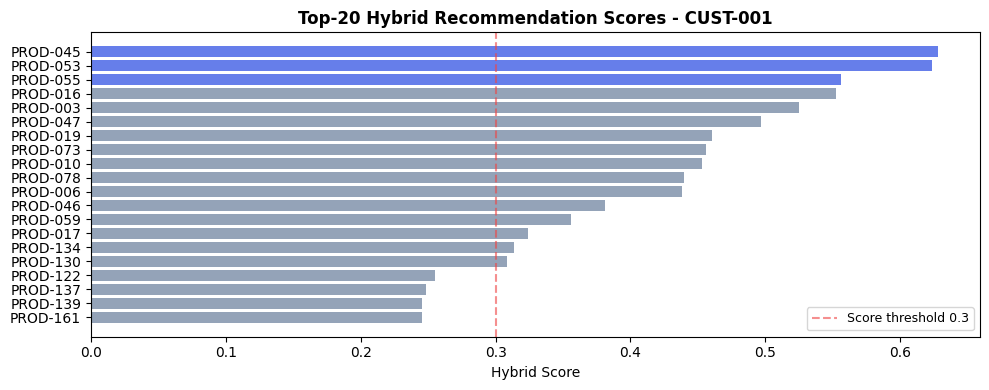


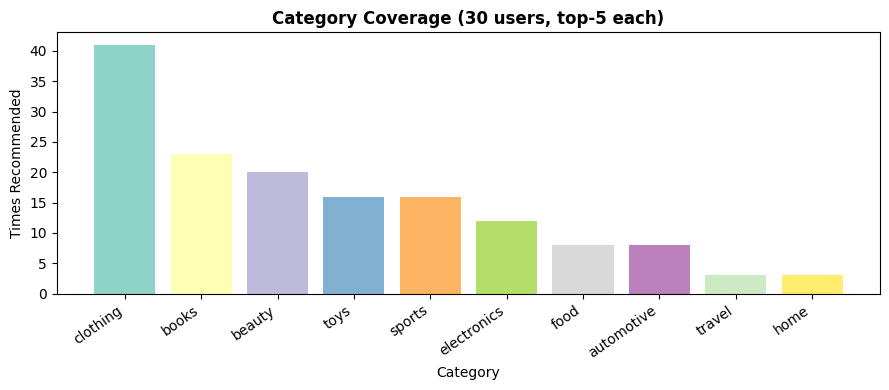

In [17]:
# ── UC8-A: Deterministic ──────────────────────────────────────────────────────
display_section('🅐 UC8-A — Visualisation (Deterministic)')

customer_id = 'CUST-001'
plot_similarity_heatmap(MATRIX, _cosine, sample_n=8)
plot_score_distribution(recommend, customer_id)
plot_category_coverage(MATRIX, PROD_MAP, recommend, sample_n=30)




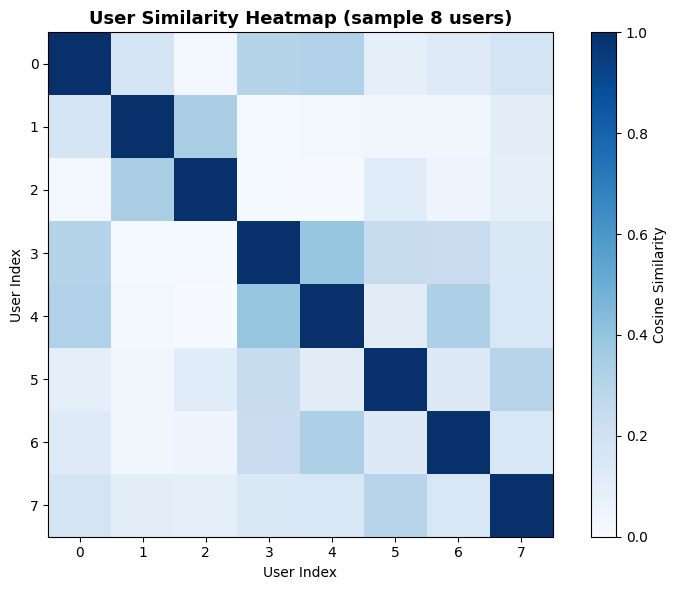


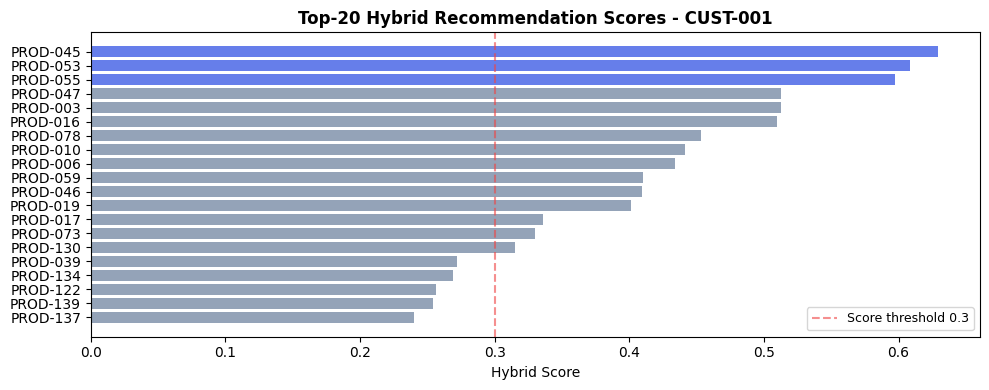


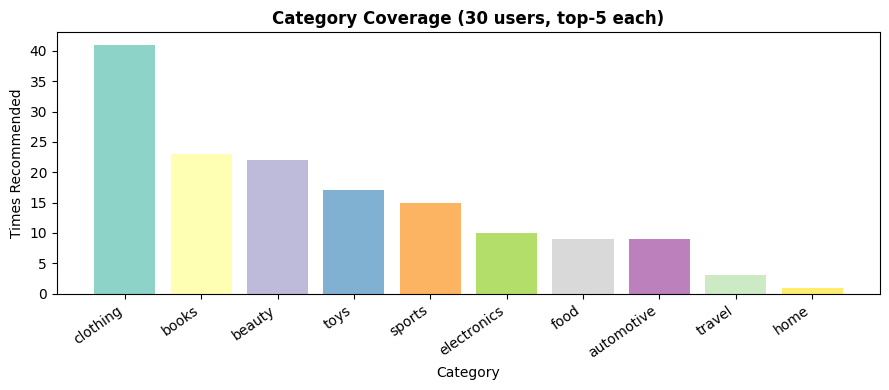

In [18]:
# ── UC8-B: Dynamic ────────────────────────────────────────────────────────────
display_section('🅑 UC8-B — Visualisation (Dynamic Agentic)')

result_b = api.execute_rec_uc8_visualisation(customer_id='CUST-001', mode='dynamic')

show_agentic_result(result_b)
show_agent_plan(result_b)
show_agent_reasoning(result_b)
show_tool_selection(result_b)
show_agent_path(result_b)
show_memory_updates(result_b)
show_mcp_calls(result_b)

# Dynamic: LLM classifies the visualisation request
viz_class = llm_mcp.classify_recommendation_request(
    'Show similarity heatmap and score distribution for CUST-001',
    {'customer_id': 'CUST-001'}
)
show_llm_request_classification(viz_class['result'])

# Output compatibility: same charts
plot_similarity_heatmap(MATRIX, _cosine, sample_n=8)
plot_score_distribution(recommend, 'CUST-001')
plot_category_coverage(MATRIX, PROD_MAP, recommend, sample_n=30)



---
## Use Case 9 — Orchestrator Routing

**Business scenario**: The orchestrator receives a free-text request and must decide which recommendation strategy to invoke.

| Version | Approach |
|---|---|
| **A — Deterministic** | Rule-based keyword routing |
| **B — Dynamic** | LLM classifies intent → registry discovers tools → planner builds execution plan |

In [19]:
# ── UC9-A: Deterministic (rule-based routing) ─────────────────────────────────
display_section('🅐 UC9-A — Orchestrator Routing (Deterministic)')

test_requests = [
    'Recommend products for CUST-001',
    'Find similar users to CUST-042',
    'Cold start recommendations for new customer',
    'Evaluate recommendation quality',
    'Segment batch recommendations for dormant_vip',
]

rows = []
for req in test_requests:
    result = llm_mcp.classify_recommendation_request(req)
    r = result['result']
    rows.append({'Request': req, 'Strategy': r['strategy'], 'Confidence': r['confidence'], 'Method': r['method']})

import pandas as pd
df = pd.DataFrame(rows)
display(df.style.set_table_styles([{'selector': 'th', 'props': [('background', '#667eea'), ('color', 'white'), ('padding', '8px')]}]))

,Request,Strategy,Confidence,Method
0,Recommend products for CUST-001,cold_start,0.850000,rule_based
1,Find similar users to CUST-042,collaborative,0.850000,rule_based
2,Cold start recommendations for new customer,cold_start,0.850000,rule_based
3,Evaluate recommendation quality,evaluation,0.850000,rule_based
4,Segment batch recommendations for dormant_vip,segment_batch,0.850000,rule_based


In [20]:
# ── UC9-B: Dynamic (planner + registry + LLM) ────────────────────────────────
display_section('🅑 UC9-B — Orchestrator Routing (Dynamic Agentic)')

routing_requests = [
    'Recommend products for CUST-001',
    'Cold start recommendations for new customer in dormant_vip segment',
    'Evaluate recommendation quality for 40 users',
]

for req in routing_requests:
    result_b = api.execute_rec_uc9_routing(req, mode='dynamic')
    show_routing_request_header(req)
    show_agentic_result(result_b)
    show_agent_plan(result_b)
    show_agent_reasoning(result_b)
    show_tool_selection(result_b)
    show_agent_path(result_b)
    show_mcp_calls(result_b)
    show_routing_divider()


---
## Summary — Nonagentic vs Agentic Comparison

| Capability | Nonagentic (A) | Agentic (B) |
|---|---|---|
| **Routing** | Fixed keyword rules | LLM intent classification |
| **Tool selection** | Hardcoded calls | Registry-based dynamic discovery |
| **SQL** | None | Dynamic safe SQL generation |
| **Feature selection** | Fixed weights | LLM-reasoned priority |
| **Explainability** | Source model label | Dominant signal + LLM explanation |
| **Memory** | None | Plan history, tool usage, observations |
| **Weight tuning** | Manual | LLM simulation proposal |
| **Cold start** | Segment fallback | LLM-selected strategy |


In [21]:
# Three-way comparison: nonagentic baseline vs deterministic agentic vs dynamic agentic
result_det = api.execute_rec_uc4_hybrid('CUST-001', top_k=10, mode='deterministic')
result_dyn = api.execute_rec_uc4_hybrid('CUST-001', top_k=10, mode='dynamic')

show_comparison(
    nonagent_result={'source': 'nonagentic', 'tools': ['recommend()']},
    deterministic_result=result_det,
    dynamic_result=result_dyn,
)